# GramArogya AI — Exploratory Data Analysis

**Goal:** understand the daily dataset and confirm the demand-forecasting problem
is *realistic* before modelling. For each driver we ask *"why should this affect
demand or resource need?"* and check the data agrees.

This notebook analyses `data/demand_resource_daily.csv` (2192 days, 68→**140
columns** after the operational-layer rebuild — see `scripts/generate_synthetic_data.py`).
The **demand** columns are unchanged; the **operational** layer (beds, inventory,
specialists, oxygen, scenarios, risk) was regenerated with realistic day-to-day
variation. See `docs/DATA_DICTIONARY.md`.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

df = pd.read_csv(ROOT / "data" / "demand_resource_daily.csv", parse_dates=["date"])
df["outbreak_type"] = df["outbreak_type"].fillna("None")
df["emergency_scenario_type"] = df["emergency_scenario_type"].fillna("None")
df = df.sort_values("date").reset_index(drop=True)

CATS = ["general_opd_arrivals", "fever_infectious_arrivals",
        "maternal_child_arrivals", "trauma_emergency_arrivals"]
print(df.shape)
df[["date", "total_patient_arrivals"] + CATS].head()

(2192, 140)


,date,total_patient_arrivals,general_opd_arrivals,fever_infectious_arrivals,maternal_child_arrivals,trauma_emergency_arrivals
0,2020-01-01,126,93,13,6,14
1,2020-01-02,124,82,19,15,8
2,2020-01-03,110,83,18,5,4
3,2020-01-04,107,70,14,9,14
4,2020-01-05,104,69,20,7,8


## Part 1 — Demand (unchanged, re-verified)

### 1.1 Demand over time

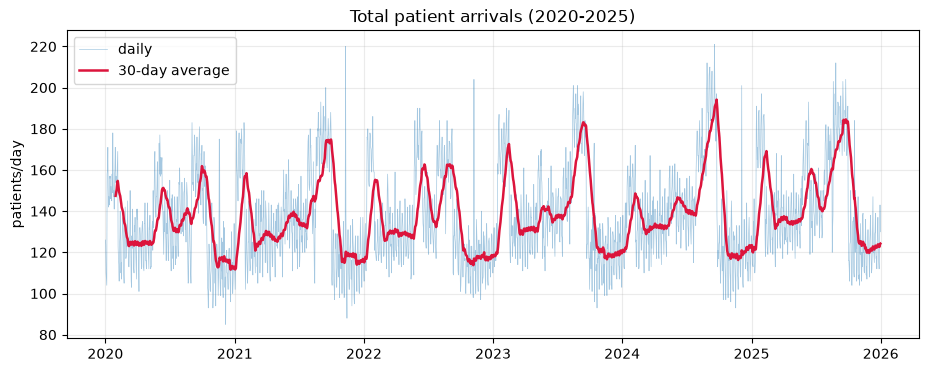

In [2]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["total_patient_arrivals"], lw=0.5, alpha=0.4, label="daily")
ax.plot(df["date"], df["total_patient_arrivals"].rolling(30).mean(),
        color="crimson", lw=1.8, label="30-day average")
ax.set_title("Total patient arrivals (2020-2025)"); ax.set_ylabel("patients/day"); ax.legend(); plt.show()

A clear repeating **annual peak** with realistic daily noise (mean ~138, range 85-221).

### 1.2 Seasonality — the monsoon fever surge

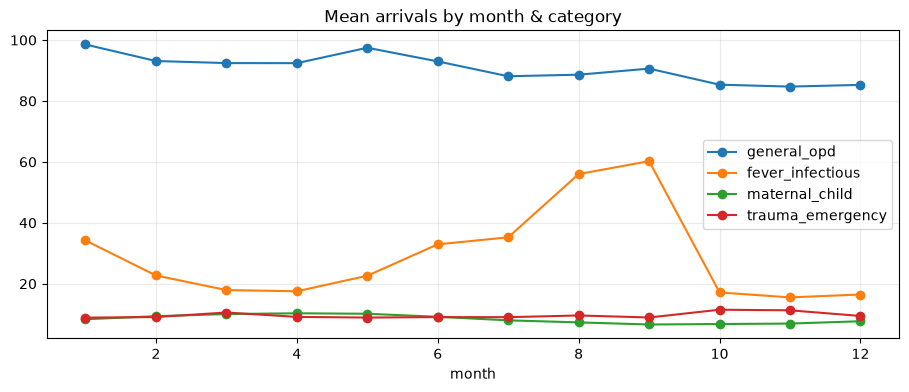

,general_opd_arrivals,fever_infectious_arrivals,maternal_child_arrivals,trauma_emergency_arrivals,total_patient_arrivals
season,,,,,
Winter,92.3,24.5,8.4,9.1,134.3
Summer,94.1,19.4,10.2,9.5,133.2
Monsoon,90.1,46.1,7.8,9.1,153.1
Post_Monsoon,85.0,16.3,6.8,11.4,119.6


In [3]:
by_month = df.groupby("month")[CATS].mean()
fig, ax = plt.subplots()
for c in CATS:
    ax.plot(by_month.index, by_month[c], marker="o", label=c.replace("_arrivals", ""))
ax.set_xlabel("month"); ax.set_title("Mean arrivals by month & category"); ax.legend(); plt.show()
df.groupby("season")[CATS + ["total_patient_arrivals"]].mean() \
  .reindex(["Winter", "Summer", "Monsoon", "Post_Monsoon"]).round(1)

**Fever/infectious** cases spike in **months 7-9 (monsoon)** (~18 → ~60/day),
mirroring vector/water-borne disease seasonality. This is the main annual peak.

### 1.3 Drivers — correlations with demand

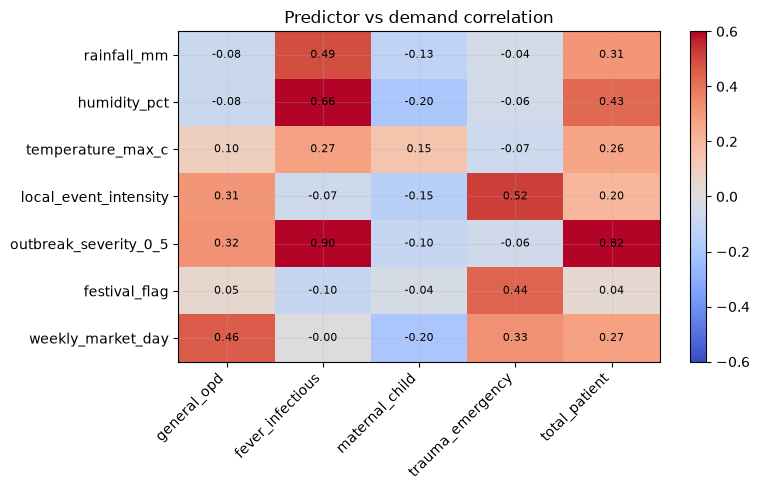

In [4]:
pred = ["rainfall_mm", "humidity_pct", "temperature_max_c", "local_event_intensity",
        "outbreak_severity_0_5", "festival_flag", "weekly_market_day"]
corr = df[pred + CATS + ["total_patient_arrivals"]].corr().loc[pred, CATS + ["total_patient_arrivals"]]
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-0.6, vmax=0.6, aspect="auto")
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels([c.replace("_arrivals", "") for c in corr.columns], rotation=45, ha="right")
ax.set_yticks(range(len(corr.index))); ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im); ax.set_title("Predictor vs demand correlation"); plt.tight_layout(); plt.show()

Each driver maps to the clinically correct category: humidity/rainfall→fever
(0.66/0.49), outbreak severity→fever/total (0.88/0.83), events/festival→trauma
(0.52/0.44), market day→OPD (0.46).

### 1.4 Disease outbreaks vs emergency scenarios (now separated)

`Mass_Casualty` was moved out of `outbreak_type` into `emergency_scenario_type`.
Disease outbreaks drive **fever**; emergency scenarios drive **trauma**.

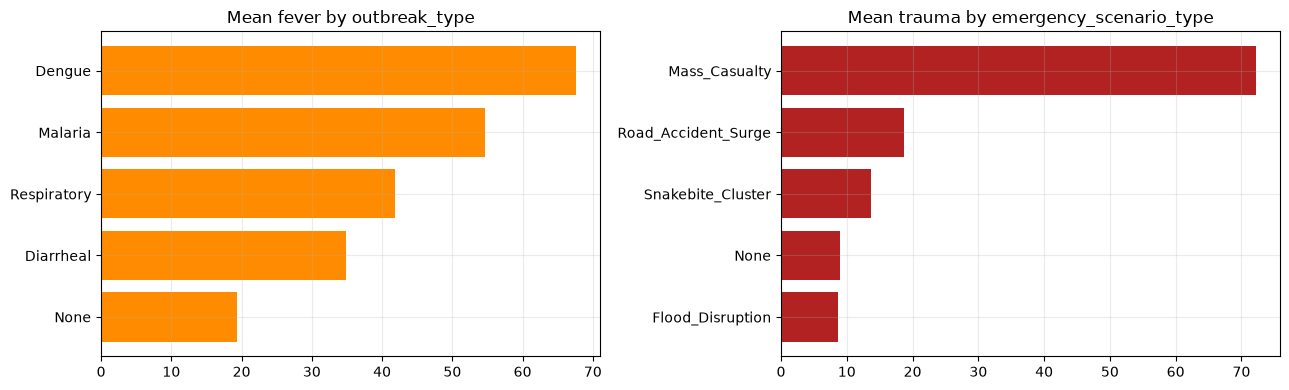

outbreak_type days: {'None': 1543, 'Dengue': 220, 'Respiratory': 162, 'Malaria': 142, 'Diarrheal': 125}
scenario days: {'None': 2008, 'Road_Accident_Surge': 87, 'Flood_Disruption': 66, 'Snakebite_Cluster': 23, 'Mass_Casualty': 8}


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ob = df.groupby("outbreak_type")["fever_infectious_arrivals"].mean().sort_values()
ax[0].barh(ob.index, ob.values, color="darkorange"); ax[0].set_title("Mean fever by outbreak_type")
sc = df.groupby("emergency_scenario_type")["trauma_emergency_arrivals"].mean().sort_values()
ax[1].barh(sc.index, sc.values, color="firebrick"); ax[1].set_title("Mean trauma by emergency_scenario_type")
plt.tight_layout(); plt.show()
print("outbreak_type days:", df["outbreak_type"].value_counts().to_dict())
print("scenario days:", df["emergency_scenario_type"].value_counts().to_dict())

Disease outbreaks (Dengue ~68 fever) load the fever channel; `Mass_Casualty`
(~72 trauma) and `Road_Accident_Surge` load trauma — cleanly separated fields.

### 1.5 Clinical subcategories (sum exactly to parents)

In [6]:
fev_sub = ["vector_borne_cases", "respiratory_cases", "gastrointestinal_cases", "other_fever_cases"]
assert (df[fev_sub].sum(axis=1) == df["fever_infectious_arrivals"]).all()
mch_sub = ["pediatric_cases", "antenatal_cases", "obstetric_emergency_cases", "immunization_visits"]
assert (df[mch_sub].sum(axis=1) == df["maternal_child_arrivals"]).all()
print("Subcategory sums reconcile with parents.")
df.groupby("outbreak_type")[fev_sub].mean().round(1)

Subcategory sums reconcile with parents.


,vector_borne_cases,respiratory_cases,gastrointestinal_cases,other_fever_cases
outbreak_type,,,,
Dengue,44.7,8.0,7.9,7.1
Diarrheal,5.9,5.1,19.6,4.3
Malaria,35.9,6.3,6.8,5.6
None,6.8,5.5,4.2,2.8
Respiratory,5.6,26.6,5.3,4.5


Fever splits shift with the outbreak (Dengue/Malaria → more `vector_borne_cases`,
Respiratory → more `respiratory_cases`, Diarrheal → more `gastrointestinal_cases`).

## Part 2 — Operational layer (regenerated)

### 2.1 Bed occupancy is sequential; overflow is rare and surge-driven

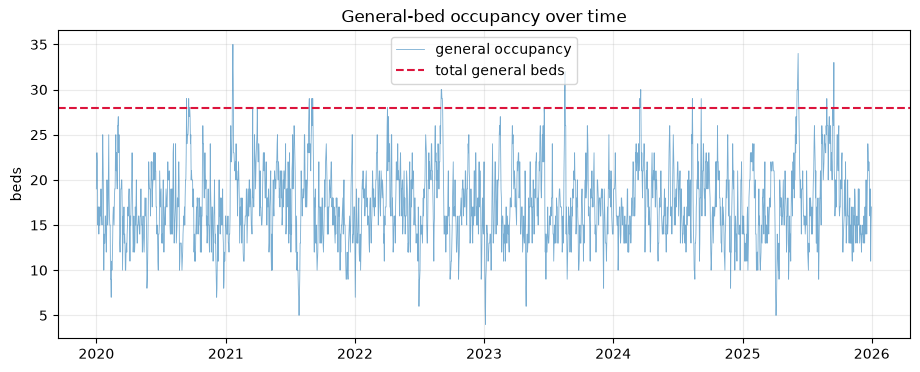

overflow days: 93 of 2192 (4.2%)
mean overflow  — event days: 0.323 | normal days: 0.011


In [7]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["projected_general_occupancy"], lw=0.6, alpha=0.6, label="general occupancy")
ax.axhline(df["total_general_beds"].iloc[0], color="crimson", ls="--", label="total general beds")
ax.set_title("General-bed occupancy over time"); ax.set_ylabel("beds"); ax.legend(); plt.show()

is_event = (df["outbreak_type"] != "None") | (df["emergency_scenario_type"] != "None")
print("overflow days:", int((df['overflow_patients'] > 0).sum()), "of", len(df),
      f"({(df['overflow_patients']>0).mean():.1%})")
print("mean overflow  — event days:", round(df.loc[is_event, "overflow_patients"].mean(), 3),
      "| normal days:", round(df.loc[~is_event, "overflow_patients"].mean(), 3))

Occupancy drifts smoothly (length-of-stay carryover) and brushes capacity on
surges. **Overflow occurs on ~4% of days**, ~30× more often on outbreak/scenario
days than normal days — the fix for the old `overflow_patients = 0` problem.

### 2.2 Specialist coverage now varies

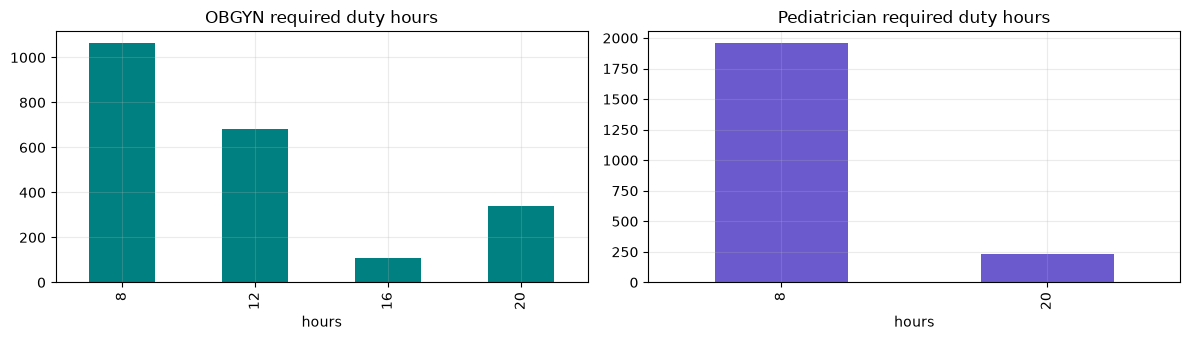

OBGYN on-call required: 0.61 | OBGYN shortage days: 449
required_obgyn_doctors: {1: 1743, 2: 449} | required_pediatricians: {1: 1957, 2: 235}


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
df["required_obgyn_duty_hours"].value_counts().sort_index().plot.bar(ax=ax[0], color="teal")
ax[0].set_title("OBGYN required duty hours"); ax[0].set_xlabel("hours")
df["required_pediatrician_duty_hours"].value_counts().sort_index().plot.bar(ax=ax[1], color="slateblue")
ax[1].set_title("Pediatrician required duty hours"); ax[1].set_xlabel("hours")
plt.tight_layout(); plt.show()
print("OBGYN on-call required:", df["obgyn_on_call_required"].mean().round(2),
      "| OBGYN shortage days:", int(df["obgyn_shortage_flag"].sum()))
print("required_obgyn_doctors:", df["required_obgyn_doctors"].value_counts().to_dict(),
      "| required_pediatricians:", df["required_pediatricians"].value_counts().to_dict())

OBGYN duty hours span 8-24 and on-call is mobilised on high-maternal days. With
only **1 OBGYN on staff**, the "minimum 2" policy flags a shortage on ~20% of
days — a realistic rural specialist gap (no longer a constant `= 1`).

### 2.3 Medicine inventory moves day-to-day, with reorders

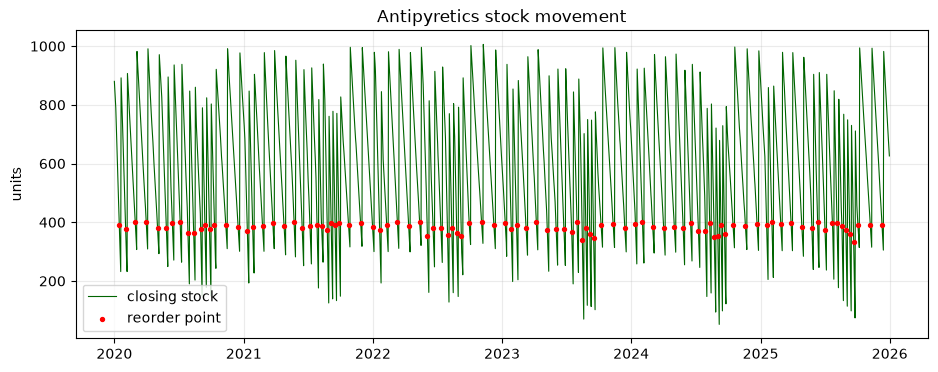

iv_fluids              closing min=  61 max= 449 reorders=121 shortage_days=0
ors                    closing min=   0 max= 361 reorders= 73 shortage_days=1
diagnostic_test_kits   closing min=   0 max= 422 reorders=134 shortage_days=13
antipyretics           closing min=  52 max=1006 reorders= 99 shortage_days=0
ppe_kits               closing min=   0 max= 592 reorders= 61 shortage_days=5


In [9]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["closing_stock_antipyretics"], lw=0.8, color="darkgreen", label="closing stock")
reorders = df[df["antipyretics_reorder_flag"] == 1]
ax.scatter(reorders["date"], reorders["closing_stock_antipyretics"], s=8, color="red", label="reorder point", zorder=5)
ax.set_title("Antipyretics stock movement"); ax.set_ylabel("units"); ax.legend(); plt.show()
for it in ["iv_fluids", "ors", "diagnostic_test_kits", "antipyretics", "ppe_kits"]:
    print(f"{it:22s} closing min={df[f'closing_stock_{it}'].min():4d} max={df[f'closing_stock_{it}'].max():4d} "
          f"reorders={int(df[f'{it}_reorder_flag'].sum()):3d} shortage_days={int((df[f'{it}_shortage_units']>0).sum())}")

Stock sawtooths — consumed daily, replenished after reorders (lead-time delivery).
`opening[t] == closing[t-1] + received[t]` holds for every item.

### 2.4 Oxygen tracks respiratory severity (not trauma)

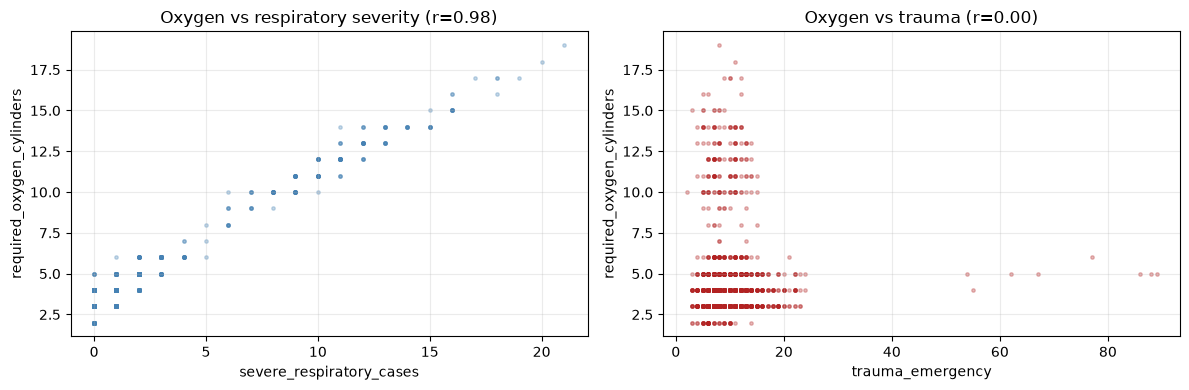

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(df["severe_respiratory_cases"], df["required_oxygen_cylinders"], s=6, alpha=0.3, color="steelblue")
ax[0].set_xlabel("severe_respiratory_cases"); ax[0].set_ylabel("required_oxygen_cylinders")
ax[0].set_title(f"Oxygen vs respiratory severity (r={df['severe_respiratory_cases'].corr(df['required_oxygen_cylinders']):.2f})")
ax[1].scatter(df["trauma_emergency_arrivals"], df["required_oxygen_cylinders"], s=6, alpha=0.3, color="firebrick")
ax[1].set_xlabel("trauma_emergency"); ax[1].set_ylabel("required_oxygen_cylinders")
ax[1].set_title(f"Oxygen vs trauma (r={df['trauma_emergency_arrivals'].corr(df['required_oxygen_cylinders']):.2f})")
plt.tight_layout(); plt.show()

Oxygen demand is driven by **respiratory severity (r≈0.98)**, not trauma
(r≈0.0) — the corrected clinical logic.

### 2.5 Emergency risk escalates with strain & scenarios

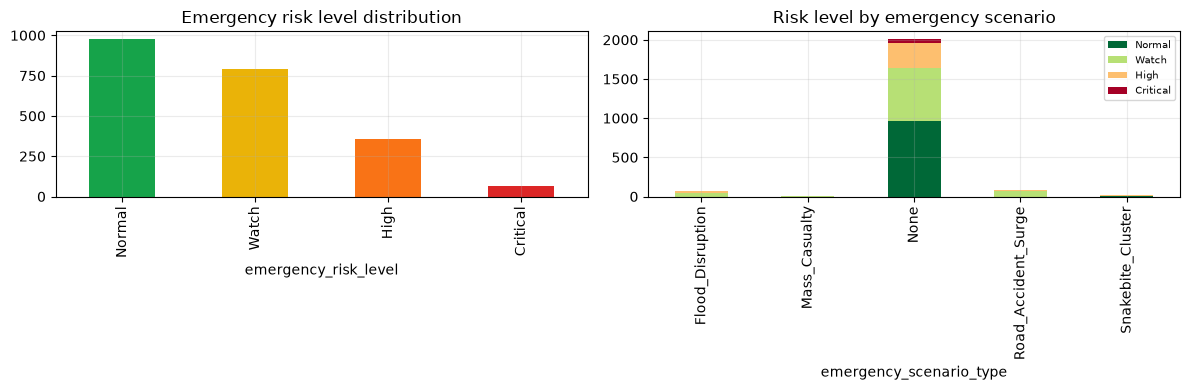

,resource_shortage_count,overflow_patients,total_patient_arrivals
emergency_risk_level,,,
Critical,1.50,3.19,178.69
High,0.71,0.14,170.69
Normal,0.00,0.00,122.76
Watch,0.89,0.00,138.02


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
order = ["Normal", "Watch", "High", "Critical"]
df["emergency_risk_level"].value_counts().reindex(order).plot.bar(ax=ax[0], color=["#16a34a","#eab308","#f97316","#dc2626"])
ax[0].set_title("Emergency risk level distribution")
ct = pd.crosstab(df["emergency_scenario_type"], df["emergency_risk_level"])[order]
ct.plot.bar(stacked=True, ax=ax[1], colormap="RdYlGn_r")
ax[1].set_title("Risk level by emergency scenario"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
df.groupby("emergency_risk_level")[["resource_shortage_count", "overflow_patients", "total_patient_arrivals"]].mean().round(2)

Risk distribution ≈ **Normal 45% / Watch 36% / High 16% / Critical 3%**.
Critical days are almost entirely outbreak/scenario days, and shortage count &
overflow rise monotonically with risk — explainable, rule-based labels.

## Part 3 — Leakage-safe feature list (for Phase 6)

The demand model predicts the targets and may use **only** Group A predictors +
lag/rolling. Every operational column is excluded.

In [12]:
LEAKAGE_SAFE_FEATURES = [
    "day_of_week_num", "week_of_year", "month", "season", "is_weekend",
    "public_holiday", "festival_flag", "weekly_market_day", "vaccination_camp_flag",
    "maternal_clinic_day", "local_event_intensity",
    "rainfall_mm", "temperature_max_c", "temperature_min_c", "humidity_pct",
    "outbreak_type", "outbreak_severity_0_5", "surveillance_alert", "affected_villages",
    "patients_lag_1", "patients_lag_2", "patients_lag_7", "patients_lag_14",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_14",
]
TARGETS = ["general_opd_arrivals", "fever_infectious_arrivals", "maternal_child_arrivals",
           "trauma_emergency_arrivals", "total_patient_arrivals", "expected_admissions"]
KEY = ["date", "day_of_week"]
EXCLUDED = [c for c in df.columns if c not in LEAKAGE_SAFE_FEATURES + TARGETS + KEY]
print(f"{len(LEAKAGE_SAFE_FEATURES)} safe features | {len(TARGETS)} targets | {len(EXCLUDED)} excluded operational cols")
assert not (set(LEAKAGE_SAFE_FEATURES) & set(EXCLUDED)), "no leakage columns in features"
assert not (set(LEAKAGE_SAFE_FEATURES) & set(TARGETS)), "no targets in features"
print("Leakage checks passed.")

26 safe features | 6 targets | 106 excluded operational cols
Leakage checks passed.


## Conclusion

- **Demand** is realistic and unchanged: monsoon fever surge, drivers map to the
  correct category, strong learnable seasonality.
- **Operational layer** now has genuine variation: sequential bed occupancy with
  rare surge-driven overflow, moving medicine inventory with reorders, varying
  specialist coverage, respiratory-driven oxygen, and explainable emergency-risk
  levels.
- The **leakage-safe feature list** (26 features) is preserved.

The dataset is ready for Phase 6 forecasting. Full write-up: `docs/EDA_FINDINGS.md`.